## N-Queens com n baixo
Contém variacoes de Plotagens
- *Luan Carlos dos Santos*
---

#### Importações

In [939]:
import random
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import time

##### Vizualização Tabuleiro

In [940]:
def plt_tabuleiro(vetor_s, titulo, d):
  # Criar matriz 8x8 alternando 0 e 1
  base_tabuleiro = np.zeros((d, d))
  base_tabuleiro[1::2, ::2] = 1
  base_tabuleiro[::2, 1::2] = 1
  
  fig, ax = plt.subplots(figsize=(d, d))
  # Exibir a matriz com mapa de cores em preto e branco
  ax.imshow(base_tabuleiro, cmap='binary')
  
  # Adicionar texto ou dados dentro de células específicas
  for i in range(len(vetor_s)):
    ax.text(vetor_s[i], i, "♛", fontsize=40, ha='center', va= 'center', color='blue')

  plt.title(titulo)
  plt.show()


##### Vizualização da Matriz Tabu

In [941]:
def plt_matrizTabu(matrizTabu):
  tam = matrizTabu.shape[0] # Obtém o tamanho n da matriz automaticamente
  tabuleiro = np.zeros((tam, tam), dtype=int)
  fig, ax = plt.subplots(figsize=(tam, tam))
  # Exibir a matriz (fundo)
  ax.imshow(tabuleiro, cmap="binary", origin="upper", interpolation='nearest')
  # Adicionar o valor exato de cada célula no gráfico com cores condicionais
  for i in range(tam):
    for j in range(tam):
      # Define a cor do texto baseada na posição
      if i == j:
          cor_texto = "green"  # Diagonal principal
      elif j > i:
          cor_texto = "red" # Triângulo superior
      else:
          cor_texto = "red"    # Triângulo inferior
      # Adiciona o número com a cor definida
      ax.text(j, i, matrizTabu[i, j], fontsize=15, ha="center", va="center", color=cor_texto)
      # Adiciona borda preta individual para cada célula
      # O retângulo é desenhado começando no canto inferior esquerdo (j-0.5, i-0.5)
      # com largura e altura de 1.0 (tamanho da célula).
      rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='gray', linewidth=1)
      ax.add_patch(rect)
  # Configurações para exibir as bordas e os eixos corretamente
  ax.set_xticks(np.arange(tam))
  ax.set_yticks(np.arange(tam))
  ax.set_xticklabels(np.arange(tam))
  ax.set_yticklabels(np.arange(tam))
  ax.grid(False) # Desativa a grade padrão para não interferir nas bordas pretas

  plt.title(f"Matriz Tabu de dimensão {d}x{d}")
  plt.tight_layout() # Ajusta o layout para não cortar elementos
  plt.show()


##### Função Objetivo

In [942]:
def funcao_objetivo(S):
  dp = []
  dn = []
  for i in range(len(S)):
    dp.append(i - S[i])
    dn.append(i + S[i])
  freq_dp = Counter(dp)
  freq_dn = Counter(dn)
  conflitos_dp = sum(qtd * (qtd - 1) // 2 for qtd in freq_dp.values() if qtd > 1)
  conflitos_dn = sum(qtd * (qtd - 1) // 2 for qtd in freq_dn.values() if qtd > 1)
  fitness = conflitos_dp + conflitos_dn
  return fitness

##### Gráfico de Convergência

In [943]:
def plt_grafico_convergencia(historico_conflitos, historico_rodadas, n_rainhas):
  plt.figure(figsize=(12, 6))

  # Plota a evolução dos conflitos
  plt.plot(historico_rodadas, historico_conflitos, linestyle='-', linewidth=0.6, color="#00FF00", label='Conflitos Atuais')

  # Adiciona a linha horizontal de meta em Y=0
  plt.axhline(y=0, color='red', linestyle='-', linewidth=0.4, label='Meta (Zero Conflitos)')

  # Customizações estéticas para o relatório
  plt.title(f'Evolução do Número de Conflitos por Iteração ({n_rainhas} Rainhas)', fontsize=14, fontweight='bold')
  plt.xlabel('Rodadas (Iterações)', fontsize=12)
  plt.ylabel('Número de Conflitos', fontsize=12)

  # Define os limites do gráfico para ficar bem enquadrado
  plt.xlim(0, max(historico_rodadas) * 1.05)
  plt.ylim(-1, max(historico_conflitos) * 1.1)

  plt.grid(True, linestyle=':', alpha=0.6)
  plt.legend(loc='upper right', fontsize=11)
  plt.show()

### Inicializações da Busca

In [944]:

#Parâmetros
n = 8
max_rodadas = 50
n_rodadas_off = 4
n_vizinhos = 2

#Analises
seed_demonstracao = 1234
random.seed(seed_demonstracao)
rejeicoes = 0
moves = 0

# Inicialização
solucao_atual = random.sample(range(0, n), n)
n_conflitos = funcao_objetivo(solucao_atual)

matriz_tabu = np.zeros((n,n), dtype=int)
np.fill_diagonal(matriz_tabu, -1)

# Resultados
otima_solucao = solucao_atual.copy()
otima_fitness = n_conflitos
hist_conflitos = [n_conflitos]
hist_rodadas = [0]

rodada = 1

### TS - Tabu Search 

In [945]:
inicio_tempo = time.time()
while rodada < max_rodadas:
  top_vizinho_rodada = None
  top_fitness_rodada = float('inf')
  top_par_pos_rodada = None  
  for i in range(n_vizinhos):
    par_pos = sorted(random.sample(range(0, n), 2))
    p1, p2 = par_pos[0], par_pos[1]
    
    solucao_atual[p1], solucao_atual[p2] = solucao_atual[p2], solucao_atual[p1]
    
    fitness_atual = funcao_objetivo(solucao_atual)

    tabu = rodada <= matriz_tabu[p1, p2]
    aspiracao = fitness_atual < otima_fitness

    if not tabu or aspiracao:
      if fitness_atual < top_fitness_rodada:
        top_fitness_rodada = fitness_atual
        top_vizinho_rodada = solucao_atual.copy()
        top_par_pos_rodada = par_pos
    else:
      rejeicoes+=1    
    solucao_atual[p1], solucao_atual[p2] = solucao_atual[p2], solucao_atual[p1]
    moves+=1
  if top_vizinho_rodada is not None:
    solucao_atual = top_vizinho_rodada.copy()
    n_conflitos = top_fitness_rodada

    p1, p2 = top_par_pos_rodada[0], top_par_pos_rodada[1]
    matriz_tabu[p1, p2] = rodada + n_rodadas_off
    matriz_tabu[p2, p1] = rodada + n_rodadas_off
  
    if n_conflitos < otima_fitness:
      otima_solucao = solucao_atual.copy()
      otima_fitness = n_conflitos
  hist_conflitos.append(otima_fitness)
  hist_rodadas.append(rodada)
  rodada+=1
  if n_conflitos == 0:
    break
tempo_total = time.time() - inicio_tempo

### Resultados

------------------------------------------------------------
   SOLUÇÃO ÓTIMA ENCONTRADA! Rodada 42 de 50, em 0.002s!
------------------------------------------------------------
Solução: [2, 6, 1, 7, 4, 0, 3, 5]
Paramêtros:
  - Número de Rainhas             : 8
  - Penalização(n_rodadas_off)    : 4
  - Número de Vizinhos            : 2
  - Número de Conflitos           : 0
Estatísticas:
  - Total de rejeições            : 7
  - Quantidade de moves(swaps)    : 82
  - Percentual de Rejeição        : 8.54%


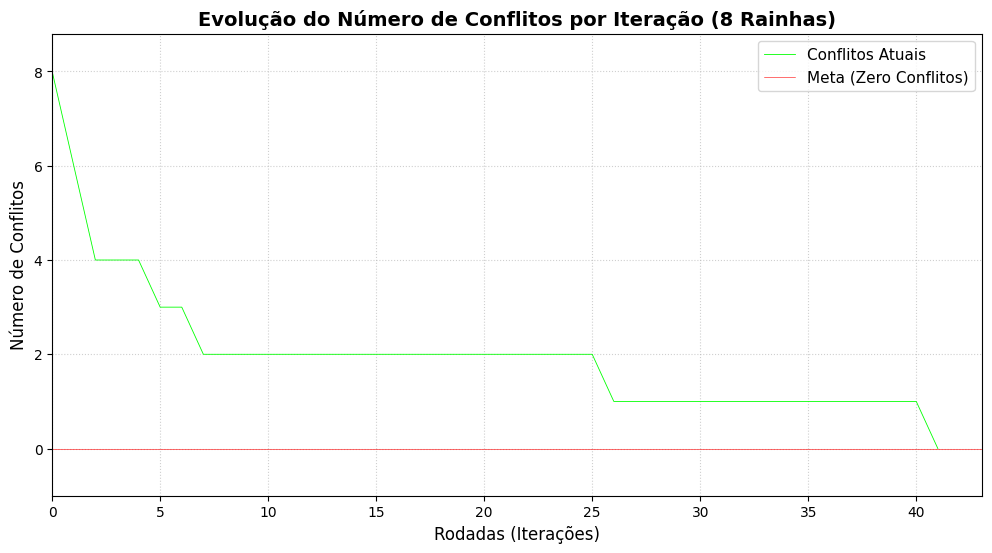

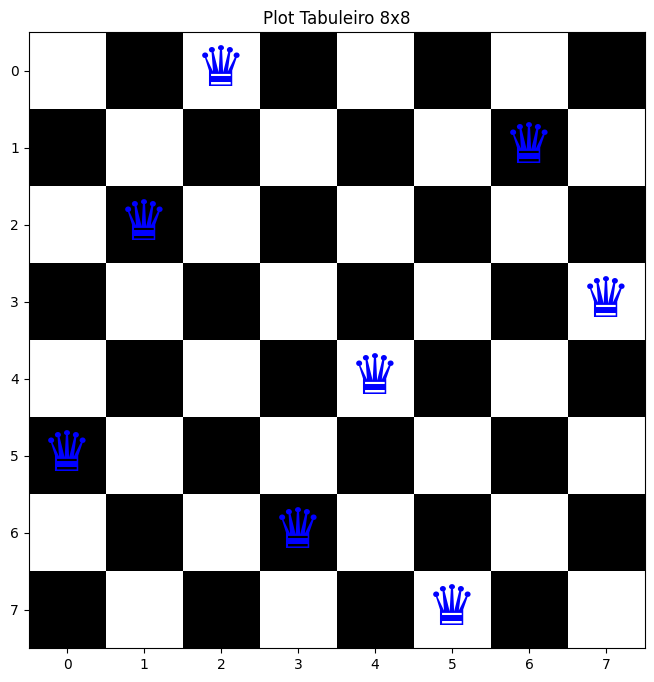

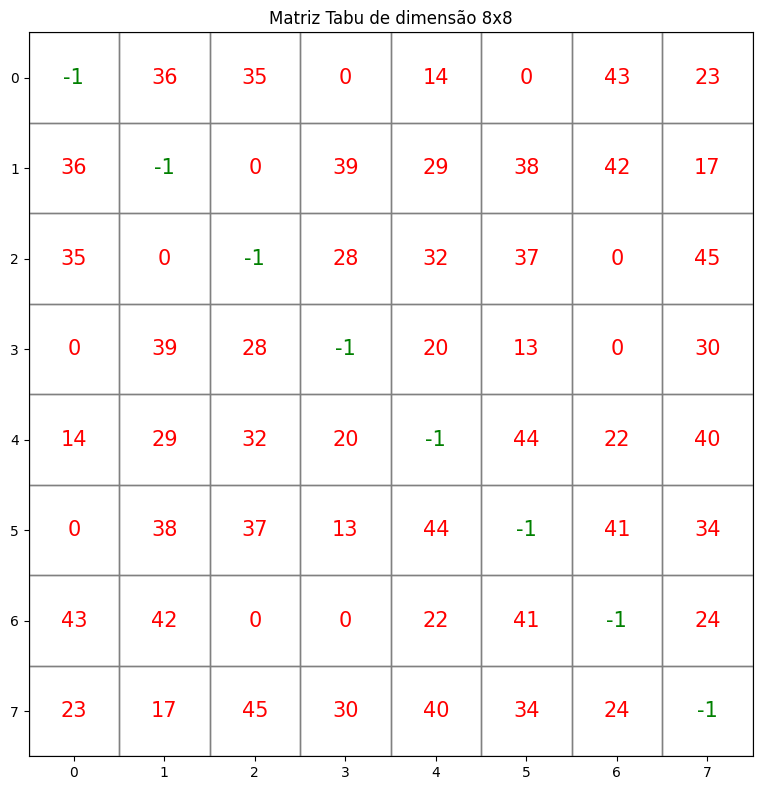

In [946]:
if rodada == max_rodadas:
  print(f'Máximo de Iterações Atingido![{rodada}/{max_rodadas}], em {tempo_total:.3f}s!')
if otima_fitness == 0:
  print(60*'-')
  print(f'   SOLUÇÃO ÓTIMA ENCONTRADA! Rodada {rodada} de {max_rodadas}, em {tempo_total:.3f}s!')
  print(60*'-')
  print(f'Solução: {otima_solucao}')
print('Paramêtros:')
print(f'  - Número de Rainhas             : {n}')
print(f'  - Penalização(n_rodadas_off)    : {n_rodadas_off}')
print(f'  - Número de Vizinhos            : {n_vizinhos}')
print(f'  - Número de Conflitos           : {n_conflitos}')
print('Estatísticas:')
print(f'  - Total de rejeições            : {rejeicoes}')
print(f'  - Quantidade de moves(swaps)    : {moves}')
print(f'  - Percentual de Rejeição        : {rejeicoes/moves*100:.2f}%')
plt_grafico_convergencia(hist_conflitos, hist_rodadas, n)
plt_tabuleiro(otima_solucao, f'Plot Tabuleiro {n}x{n}', n)
plt_matrizTabu(matriz_tabu)